In [49]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch, torch_scatter, numpy as np, networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

from src.utils.config import load_cfg
from src.utils.graph_generation import get_dataset
from src.models.module import SALSACLRSModel, calc_metrics

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")

CONFIG_PATH = os.path.join(project_root, "src/configs/bfs/GIN-residual-grok-hl.yml")
CHECKPOINT_PATH = "/home/marko/projects/gdg/nar-experiments/data/checkpoints/bfs/GIN-residual-hints-HL/seed42-epoch=37-step=11894.ckpt"


Project root: /home/marko/projects/gdg/nar-experiments
PyTorch version: 2.8.0+cu128


In [50]:
def fix_batch_attributes(batch):
    # Fix PyG Batch nested-list attributes created by from_data_list.
    for attr in ("inputs", "outputs", "hints"):
        val = getattr(batch, attr, None)
        if isinstance(val, list) and val and isinstance(val[0], list):
            setattr(batch, attr, val[0])
    batch.inputs  = ["pos", "s"]
    batch.outputs = ["pi"]
    batch.hints   = ["reach_h", "pi_h"]
    return batch

# ---- pointer helpers ----

def pred_parent_per_node(pred_pi, edge_index, num_nodes):
    # Return tensor[N]: entry n = predicted parent of node n.
    # pred_pi shape [E], edge_index shape [2, E]
    _, argmax_edge = torch_scatter.scatter_max(
        pred_pi, edge_index[0], dim=-1, dim_size=num_nodes
    )
    valid = argmax_edge < edge_index.shape[1]
    parent = torch.arange(num_nodes)
    parent[valid] = edge_index[1, argmax_edge[valid]]
    return parent

def true_parent_per_node(pi, edge_index, num_nodes):
    # Return tensor[N]: entry n = ground-truth parent of node n.
    # pi shape [E] (1.0 for BFS-tree edges, 0.0 otherwise)
    _, argmax_edge = torch_scatter.scatter_max(
        pi.float(), edge_index[0], dim=-1, dim_size=num_nodes
    )
    valid = argmax_edge < edge_index.shape[1]
    parent = torch.arange(num_nodes)
    parent[valid] = edge_index[1, argmax_edge[valid]]
    return parent

# ---- graph construction ----

def build_undirected_graph(edge_index, num_nodes):
    # Build an undirected NetworkX graph from a PyG edge_index.
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    seen = set()
    for i in range(edge_index.shape[1]):
        u, v = int(edge_index[0, i]), int(edge_index[1, i])
        key = (min(u, v), max(u, v))
        if key not in seen:
            seen.add(key)
            G.add_edge(u, v)
    return G

# ---- main drawing function ----

def draw_comparison_graph(data, pred_pi, *, ax=None, title=None,
                          layout="spring", seed=42):
    # Visualize predicted vs GT BFS predecessor tree.
    # Arrow convention: child --> parent (predecessor pointer direction)
    # green = correct, red = incorrect, gray dashed = missed GT parent
    num_nodes = data.s.shape[0]
    source    = data.s.argmax().item()
    G         = build_undirected_graph(data.edge_index, num_nodes)

    pred_par  = pred_parent_per_node(pred_pi, data.edge_index, num_nodes).numpy()
    true_par  = true_parent_per_node(data.pi,  data.edge_index, num_nodes).numpy()

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(8, 6))

    pos = (nx.kamada_kawai_layout(G) if layout == "kamada_kawai"
           else nx.spring_layout(G, seed=seed, k=2.0 / np.sqrt(num_nodes)))

    # base undirected edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#d0d0d0", width=1.0, alpha=0.8)

    correct_edges   = []
    incorrect_edges = []
    missing_edges   = []

    for n in range(num_nodes):
        if n == source:
            continue
        pp = pred_par[n]   # predicted parent
        tp = true_par[n]   # true parent
        if pp != n:        # model made a prediction
            if pp == tp:
                correct_edges.append((n, pp))     # child -> parent (green)
            else:
                incorrect_edges.append((n, pp))   # child -> wrong parent (red)
        if tp != n and pp != tp:                  # GT parent was missed
            missing_edges.append((n, tp))         # child -> true parent (gray)

    def _draw_directed(edgelist, color, width, style="solid"):
        if not edgelist:
            return
        dG = nx.DiGraph()
        dG.add_nodes_from(G.nodes())
        dG.add_edges_from(edgelist)
        nx.draw_networkx_edges(
            dG, pos, edgelist=edgelist, ax=ax,
            edge_color=color, width=width, alpha=0.9,
            arrows=True, arrowstyle='-|>', arrowsize=15,
            connectionstyle='arc3,rad=0.1', style=style,
        )

    _draw_directed(correct_edges,   "#2a9d8f", 2.5)
    _draw_directed(incorrect_edges, "#e63946", 2.5)
    _draw_directed(missing_edges,   "#6c757d", 2.0, style="dashed")

    # nodes
    reachable   = [n for n in G.nodes() if n != source and true_par[n] != n]
    unreachable = [n for n in G.nodes() if n != source and true_par[n] == n]
    if unreachable:
        nx.draw_networkx_nodes(G, pos, nodelist=unreachable, ax=ax,
                               node_color="#bbb", node_size=300, edgecolors="#888")
    if reachable:
        nx.draw_networkx_nodes(G, pos, nodelist=reachable, ax=ax,
                               node_color="#457b9d", node_size=300, edgecolors="#1d3557")
    nx.draw_networkx_nodes(G, pos, nodelist=[source], ax=ax,
                           node_color="#f4a261", node_size=500,
                           node_shape="*", edgecolors="#e76f51")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")

    ax.legend(handles=[
        Line2D([0],[0], color='#2a9d8f', lw=2.5, label='Correct parent'),
        Line2D([0],[0], color='#e63946', lw=2.5, label='Incorrect parent'),
        Line2D([0],[0], color='#6c757d', lw=2.0, ls='--', label='Missing GT parent'),
    ], loc="best", fontsize=7)

    if title:
        ax.set_title(title)
    ax.axis("off")
    return pos


In [51]:
cfg = load_cfg(CONFIG_PATH)
cfg.DATA.ROOT = os.path.join(project_root, "data")
print(f"Config: {cfg.RUN_NAME}")

train_ds = get_dataset("train", cfg)
model = SALSACLRSModel.load_from_checkpoint(CHECKPOINT_PATH,
                                            specs=train_ds.specs, cfg=cfg)
model.eval()

test_datasets = get_dataset("test", cfg)
print(f"Loaded {len(test_datasets)} test datasets.")


2026-03-08 02:25:15.027 | INFO     | src.utils.graph_generation:get_dataset:66 - Using custom generator params from config for train: [{'n': [4, 7, 11, 13, 16], 'p_range': [0.17, 0.52]}, {'n': [11, 13, 16, 20], 'p_range': [0.05, 0.2], 'k': [4, 6, 8]}, {'n': [4, 7, 11, 13, 16]}]


Config: GIN-residual-grokking-hl
Loading bfs dataset for split: train...


2026-03-08 02:25:15.220 | DEBUG    | src.models.models:_gin_module:31 - Using batch norm in GIN module
2026-03-08 02:25:15.221 | DEBUG    | src.models.models:_gin_module:37 - Using batch norm in GIN module
2026-03-08 02:25:15.223 | DEBUG    | src.models.models:__init__:113 - Ignoring output encoder for pi
2026-03-08 02:25:15.223 | DEBUG    | src.models.models:__init__:110 - Ignoring hint encoder for reach_h
2026-03-08 02:25:15.223 | DEBUG    | src.models.models:__init__:110 - Ignoring hint encoder for pi_h
2026-03-08 02:25:15.224 | DEBUG    | src.models.models:__init__:284 - Ignoring input decoder for pos
2026-03-08 02:25:15.224 | DEBUG    | src.models.models:__init__:284 - Ignoring input decoder for s
2026-03-08 02:25:15.226 | DEBUG    | src.models.models:__init__:353 - Decoder: False
2026-03-08 02:25:15.230 | INFO     | src.utils.graph_generation:get_dataset:66 - Using custom generator params from config for test: [{'p_range': [0.173, 0.52], 'n': 16}, {'p_range': [0.054, 0.164], 'n':

Loading bfs dataset for split: test...
Loaded 9 test datasets.


In [52]:
from torch_geometric.data import Batch

results = []
for name, ds in test_datasets.items():
    ga, na = [], []
    with torch.no_grad():
        for i in range(min(len(ds), 20)):
            batch = Batch.from_data_list([ds[i]])
            batch = fix_batch_attributes(batch)
            output, hints, hidden = model(batch)
            m = calc_metrics("pi", output, batch, model.specs["pi"][2])
            ga.append(m["graph_result"].float().mean().item())
            na.append(m["node_accuracy"].float().mean().item())
    results.append({"Dataset": name,
                    "Graph Accuracy": np.mean(ga),
                    "Node Accuracy":  np.mean(na)})

display(pd.DataFrame(results))


2026-03-08 02:25:15.253 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.253 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.282 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.284 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.320 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.321 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.343 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.344 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.361 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.361 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.383 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:15.384 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:15.413 | DE

,Dataset,Graph Accuracy,Node Accuracy
0,er_16,1.0,1.00000
1,er_80,0.0,0.97250
2,er_800,0.0,0.93100
3,ws_16,1.0,1.00000
4,ws_80,0.0,0.87000
5,ws_800,0.0,0.63500
6,delaunay_16,1.0,1.00000
7,delaunay_80,0.0,0.88250
8,delaunay_800,0.0,0.38475


2026-03-08 02:25:24.328 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:24.329 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:24.404 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:24.405 | DEBUG    | src.models.models:forward:124 - Encoding s
2026-03-08 02:25:24.497 | DEBUG    | src.models.models:forward:124 - Encoding pos
2026-03-08 02:25:24.498 | DEBUG    | src.models.models:forward:124 - Encoding s


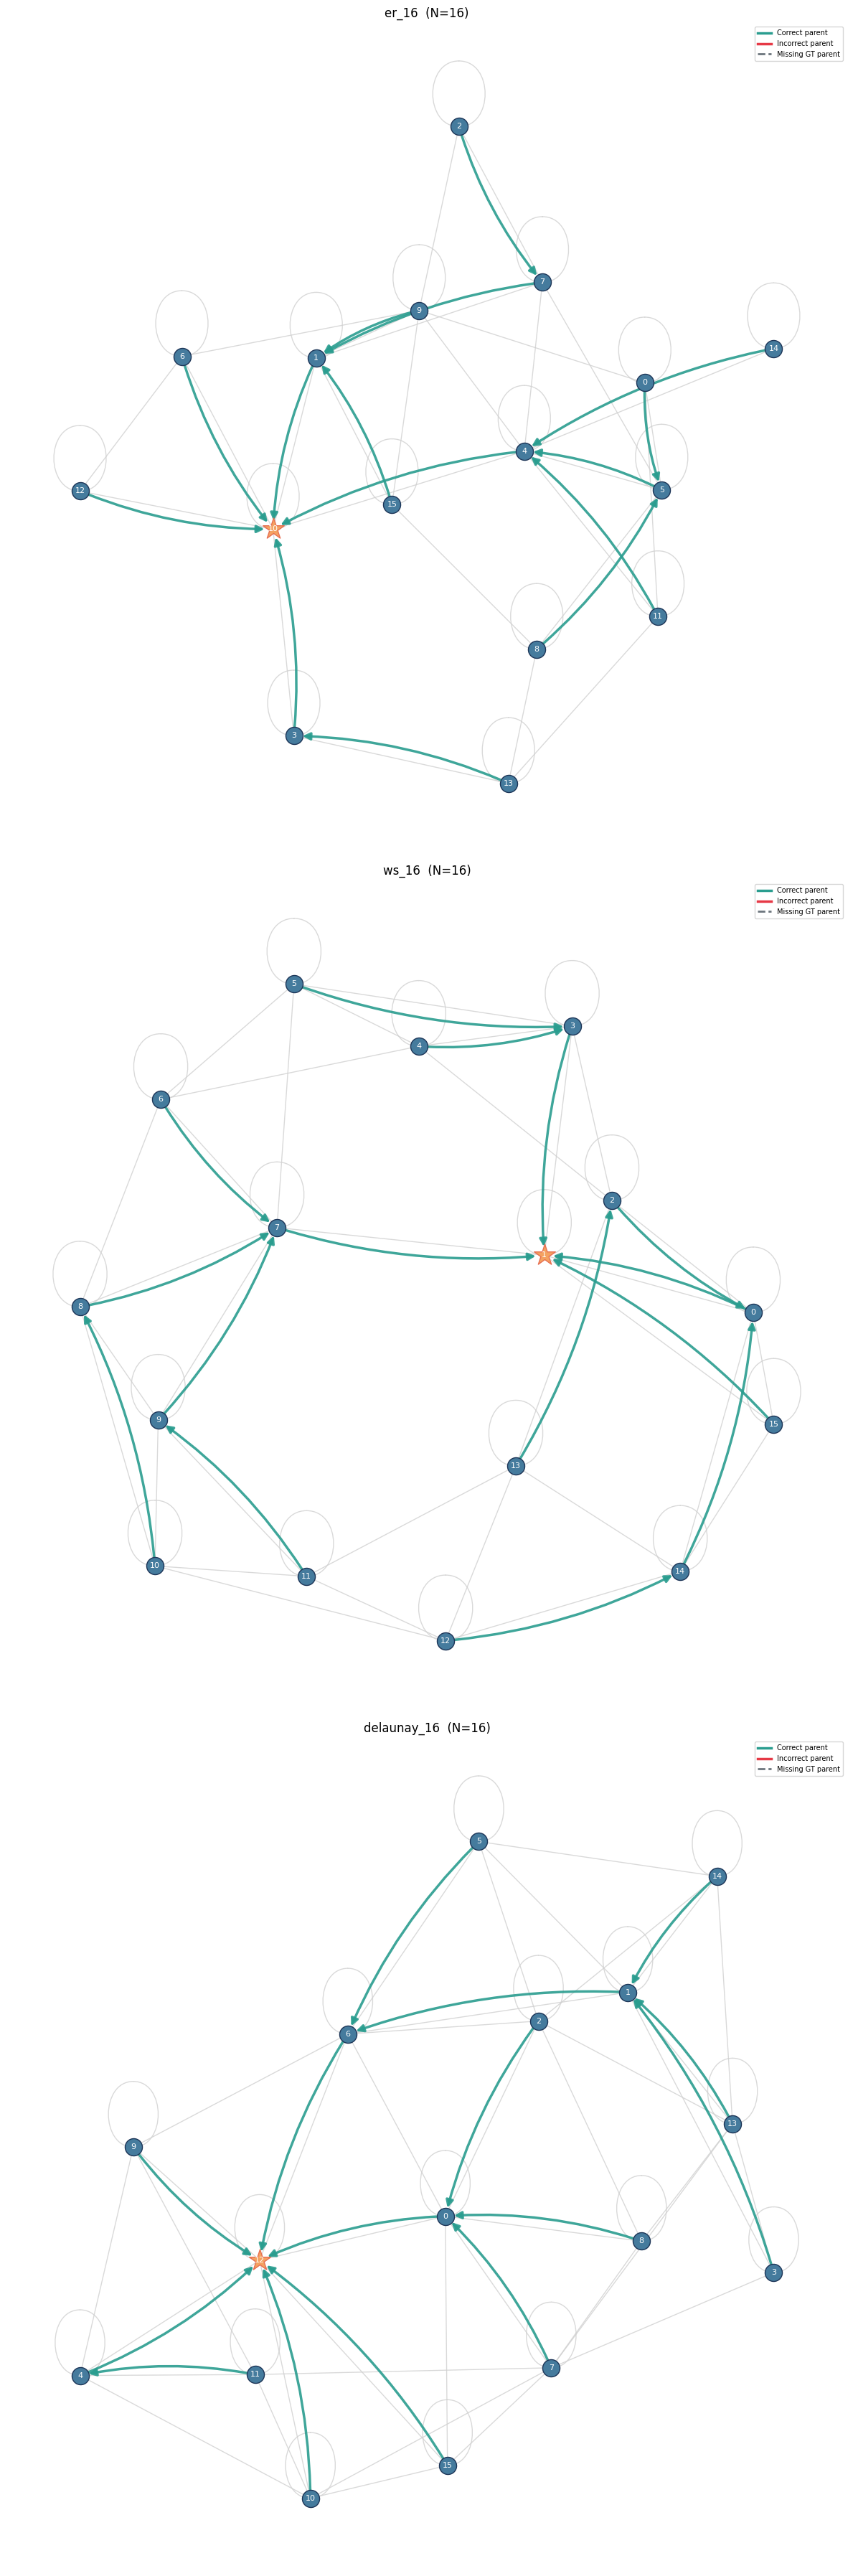

In [54]:
target_sets = ["er_16", "ws_16", "delaunay_16"]

fig, axes = plt.subplots(3, 1, figsize=(12, 36))
axes = axes.flatten()

from torch_geometric.data import Batch

for i, ds_name in enumerate(target_sets):
    if ds_name not in test_datasets:
        axes[i].set_visible(False)
        continue
    ds = test_datasets[ds_name]
    sample = ds[0]
    batch = Batch.from_data_list([sample])
    batch = fix_batch_attributes(batch)

    with torch.no_grad():
        output, hints, hidden = model(batch)

    draw_comparison_graph(
        sample, output["pi"],
        ax=axes[i],
        title=f"{ds_name}  (N={sample.num_nodes})",
        layout="kamada_kawai" if sample.num_nodes < 50 else "spring",
    )

plt.tight_layout()
plt.show()
